# 1 - Environment & Config

In [7]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# MLOps Config
CONFIG = {
    "data_path": "/kaggle/input/datasets/rakannimer/air-passengers/AirPassengers.csv",
    "window_size": 12,
    "train_split": 0.8,
    "hidden_size": 64,
    "num_layers": 2,
    "lr": 0.001,
    "epochs": 300,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

# 2 - Data Pipeline

In [8]:
def load_and_preprocess(path):
    """
    Optimized data pipeline for RNNs.
    Converts lists to NumPy arrays before Tensor conversion to avoid performance bottlenecks.
    """
    # 1. Load data
    df = pd.read_csv(path)
    df.columns = ['Month', 'Passengers']
    
    # 2. Scale data for RNN stability (crucial for tanh/sigmoid activations)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled_data = scaler.fit_transform(df['Passengers'].values.reshape(-1, 1))
    
    # 3. Create Sliding Windows
    X_list, y_list = [], []
    window = CONFIG['window_size']
    
    for i in range(len(scaled_data) - window):
        X_list.append(scaled_data[i : i + window])
        y_list.append(scaled_data[i + window])
        
    # 4. Convert lists to intermediate NumPy arrays (Fixes the UserWarning)
    X_np = np.array(X_list, dtype=np.float32)
    y_np = np.array(y_list, dtype=np.float32)
    
    # 5. Split using time-series logic (no shuffling)
    split = int(len(X_np) * CONFIG['train_split'])
    
    # 6. Convert to Tensors and send to device
    X_train = torch.from_numpy(X_np[:split]).to(CONFIG['device'])
    y_train = torch.from_numpy(y_np[:split]).to(CONFIG['device'])
    X_test  = torch.from_numpy(X_np[split:]).to(CONFIG['device'])
    y_test  = torch.from_numpy(y_np[split:]).to(CONFIG['device'])
    
    return X_train, y_train, X_test, y_test, scaler

# Execute the pipeline
X_train, y_train, X_test, y_test, scaler = load_and_preprocess(CONFIG['data_path'])

print(f" Data Ready!")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes:  X={X_test.shape}, y={y_test.shape}")

 Data Ready!
Training shapes: X=torch.Size([105, 12, 1]), y=torch.Size([105, 1])
Testing shapes:  X=torch.Size([27, 12, 1]), y=torch.Size([27, 1])


# 3 - Model 

In [9]:
class PassengerRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Initializing hidden state is best practice for RNNs
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.rnn.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        return self.fc(out[:, -1, :])

model = PassengerRNN(hidden_size=CONFIG['hidden_size'], num_layers=CONFIG['num_layers']).to(CONFIG['device'])

# 4 - Training & Logging Loop

Epoch 0 | Loss: 0.436322
Epoch 10 | Loss: 0.088376
Epoch 20 | Loss: 0.038356
Epoch 30 | Loss: 0.027318
Epoch 40 | Loss: 0.024233
Epoch 50 | Loss: 0.020697
Epoch 60 | Loss: 0.019150
Epoch 70 | Loss: 0.018501
Epoch 80 | Loss: 0.014449
Epoch 90 | Loss: 0.014715
Epoch 100 | Loss: 0.014926
Epoch 110 | Loss: 0.014682
Epoch 120 | Loss: 0.012378
Epoch 130 | Loss: 0.010607
Epoch 140 | Loss: 0.010202
Epoch 150 | Loss: 0.009230
Epoch 160 | Loss: 0.009997
Epoch 170 | Loss: 0.010321
Epoch 180 | Loss: 0.007865
Epoch 190 | Loss: 0.007317
Epoch 200 | Loss: 0.006678
Epoch 210 | Loss: 0.006528
Epoch 220 | Loss: 0.005888
Epoch 230 | Loss: 0.006512
Epoch 240 | Loss: 0.007860
Epoch 250 | Loss: 0.004696
Epoch 260 | Loss: 0.007351
Epoch 270 | Loss: 0.005609
Epoch 280 | Loss: 0.004348
Epoch 290 | Loss: 0.004890


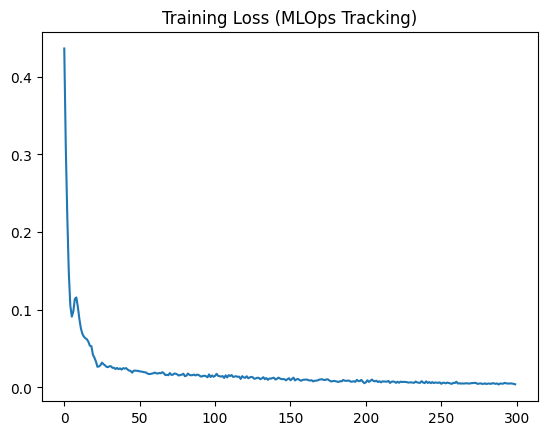

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])

# Move data to device
X_train, y_train = X_train.to(CONFIG['device']), y_train.to(CONFIG['device'])

history = []
for epoch in range(CONFIG['epochs']):
    model.train()
    optimizer.zero_grad()
    
    output = model(X_train)
    loss = criterion(output, y_train)
    
    loss.backward()
    optimizer.step()
    
    history.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

plt.plot(history)
plt.title("Training Loss (MLOps Tracking)")
plt.show()

# 5 - Evaluation & Inference

Evaluation Complete
Validation Root Mean Squared Error: 31.95 Passengers


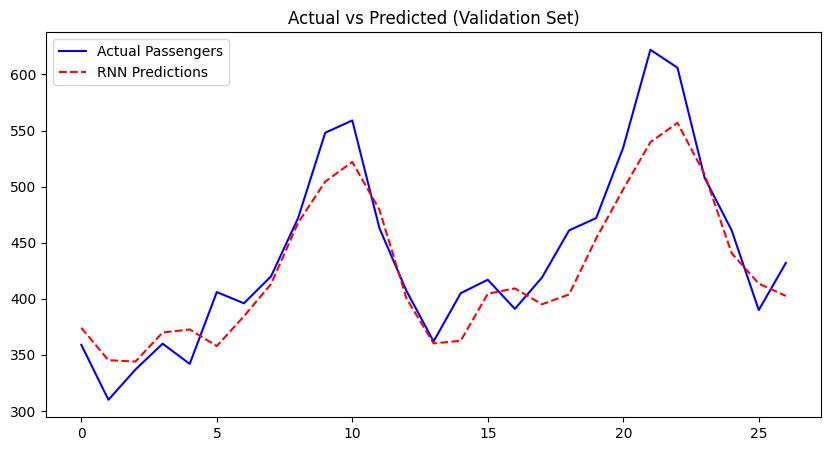

In [11]:
model.eval()
with torch.no_grad():
    # 1. Get predictions and move to CPU immediately
    test_preds = model(X_test)
    
    # 2. Inverse scale both predictions and actual values
    # We add .cpu() to y_test to fix the TypeError
    actual_preds = scaler.inverse_transform(test_preds.cpu().numpy())
    actual_y = scaler.inverse_transform(y_test.cpu().numpy())

# 3. Performance Metric (RMSE)
rmse = np.sqrt(np.mean((actual_preds - actual_y)**2))

print(f"Evaluation Complete")
print(f"Validation Root Mean Squared Error: {rmse:.2f} Passengers")

# 4. Optional: Quick Visualization of results
plt.figure(figsize=(10, 5))
plt.plot(actual_y, label='Actual Passengers', color='blue')
plt.plot(actual_preds, label='RNN Predictions', color='red', linestyle='--')
plt.title("Actual vs Predicted (Validation Set)")
plt.legend()
plt.show()

# 6 - saving the model and its metadata for deployment

In [12]:
# Save the model weights AND the scaler (the scaler is critical for future inference)
save_dir = "production_model"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), f"{save_dir}/rnn_weights.pth")
import joblib
joblib.dump(scaler, f"{save_dir}/data_scaler.pkl")

print("Model and Scaler registered for production.")

Model and Scaler registered for production.
